# 1. Imports & Setup

In [1]:
import os, sys

ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if ROOT not in sys.path:
    sys.path.append(ROOT)

import json
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from utils.helpers.url_filter import normalize_url, looks_benign, probable_phish
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    ConfusionMatrixDisplay
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)



# 2. Load unified CSV and build URL subset

In [3]:
# Adjust the path if needed
csv_path = "../../datasets/url_feeds/processed/final_urls.csv"
df = pd.read_csv(csv_path)

# Ensure urls column exists & is string
df["urls"] = df["url"].fillna("").astype(str).str.strip()

# Keep only rows where we actually have URLs
url_df = df[df["urls"].str.len() > 0].copy()
print(f"Total rows in full dataset                  : {len(df):,}")
print(f"Rows with at least one URL                  : {len(url_df):,}")

# Normalize
url_df["urls_norm"] = url_df["url"].astype(str).apply(normalize_url)
url_df = url_df[url_df["urls_norm"].str.len() > 0].copy()
print(f"[INFO] Rows after normalization (non-empty) : {len(url_df):,}")

# print("\n=== URL CLEANING PIPELINE START ===")
# before_rows = len(url_df)

# # 1) Remove images / tracking URLs
# url_df = url_df[~url_df["urls_norm"].apply(looks_benign)]

# # 2) Split labels
# phish_df = url_df[url_df["label"] == 1].copy()
# legit_df = url_df[url_df["label"] == 0].copy()

# # 3) Phishing class → keep ONLY URLs with phishing-like patterns
# phish_df = phish_df[phish_df["urls_norm"].apply(probable_phish)]

# # 4) keep only non-phishing-like URLs
# legit_df = legit_df[~legit_df["urls_norm"].apply(probable_phish)]

# # 5) Recombine
# clean_df = pd.concat([phish_df, legit_df], axis=0)
# clean_df = clean_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

# after_rows = len(clean_df)

# print(f"Before cleaning: {before_rows:,}")
# print(f"After cleaning:  {after_rows:,}")
# print("\nLabel distribution after cleaning:")
# print(clean_df['label'].value_counts())

# # Replace url_df with cleaned version
# url_df = clean_df.copy()
# print("\n=== URL CLEANING PIPELINE END ===")

# ---- CLEAN LABELS BEFORE ANY SPLIT ----
url_df = url_df[url_df["label"].notna()].copy()
url_df["label"] = url_df["label"].astype(int)

print("\n[INFO] Label distribution (no balancing):")
print(url_df["label"].value_counts())

balanced_df = url_df

# Optional: URL length stats
url_lengths = balanced_df["urls_norm"].apply(len)
print("URL text length (min, max, avg):", url_lengths.min(), url_lengths.max(), url_lengths.mean())

Total rows in full dataset                  : 10,684,070
Rows with at least one URL                  : 10,684,070
[INFO] Rows after normalization (non-empty) : 10,684,070

[INFO] Label distribution (no balancing):
label
0    5522517
1    5161553
Name: count, dtype: int64
URL text length (min, max, avg): 2 6089 23.752480374988185


# 3. Train/Val split

In [5]:
train_df, val_df = train_test_split(
    balanced_df[["urls_norm", "label"]],
    test_size=0.1,
    random_state=SEED,
    stratify=balanced_df["label"],
)

print(f"Train size: {len(train_df):,}")
print(f"Val size:   {len(val_df):,}")
print(train_df['label'].value_counts())
print(val_df['label'].value_counts())

Train size: 9,615,663
Val size:   1,068,407
label
0    4970265
1    4645398
Name: count, dtype: int64
label
0    552252
1    516155
Name: count, dtype: int64


# 4. Character vocabulary construction

In [6]:
def build_char_vocab(series, extra_chars=None):
    """
    Build a character vocabulary from a pandas Series of strings.
    Returns:
        char2idx, idx2char
    """
    chars = set()
    for text in series:
        for ch in text:
            chars.add(ch)

    if extra_chars:
        chars.update(extra_chars)

    # Reserve:
    # 0 -> PAD, 1 -> UNK
    sorted_chars = sorted(chars)
    char2idx = {"<PAD>": 0, "<UNK>": 1}
    idx2char = {0: "<PAD>", 1: "<UNK>"}

    for i, ch in enumerate(sorted_chars, start=2):
        char2idx[ch] = i
        idx2char[i] = ch

    return char2idx, idx2char


# Build vocabulary on training URLs only (avoid leakage)
char2idx, idx2char = build_char_vocab(train_df["urls_norm"])
vocab_size = len(char2idx)
print("Vocab size (including PAD/UNK):", vocab_size)

# Save vocab for later use
os.makedirs("url_charcnn_model", exist_ok=True)
with open("url_charcnn_model/char_vocab.json", "w", encoding="utf-8") as f:
    json.dump(char2idx, f, ensure_ascii=False, indent=2)


Vocab size (including PAD/UNK): 265


# 5. URL encoding helpers

In [7]:
MAX_LEN = 384  # you can tune to 384/512 if VRAM allows

def encode_url_text(text, char2idx, max_len=MAX_LEN):
    """
    Turn a URL string (possibly multiple URLs separated by spaces)
    into a fixed-length int sequence.
    """
    # For simplicity: just use the raw string (already contains http://, /, ?, etc.)
    # If you want, you can normalize here (lowercase, strip schemes, etc.)
    text = str(text)

    ids = []
    for ch in text:
        idx = char2idx.get(ch, char2idx["<UNK>"])
        ids.append(idx)
        if len(ids) >= max_len:
            break

    if len(ids) < max_len:
        ids = ids + [char2idx["<PAD>"]] * (max_len - len(ids))

    return np.array(ids, dtype=np.int64)


# Quick sanity check
example_url = train_df["urls_norm"].iloc[0]
print("Example URL text:", example_url[:120], "...")
print("Encoded sample (first 20 ids):", encode_url_text(example_url, char2idx)[:20])

Example URL text: chatwhhatsapp-com.duckdns.org ...
Encoded sample (first 20 ids): [64 69 62 81 84 69 69 62 81 80 62 77 77 36 64 76 74 37 65 82]


# 6. PyTorch Dataset & DataLoaders

In [8]:
class UrlDataset(Dataset):
    def __init__(self, df, char2idx, max_len=MAX_LEN):
        self.texts = df["urls_norm"].tolist()
        self.labels = df["label"].astype(int).tolist()
        self.char2idx = char2idx
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        input_ids = encode_url_text(text, self.char2idx, self.max_len)
        return {
            "input_ids": torch.tensor(input_ids, dtype=torch.long),
            "labels": torch.tensor(label, dtype=torch.long),
        }


train_dataset = UrlDataset(train_df, char2idx, MAX_LEN)
val_dataset   = UrlDataset(val_df,   char2idx, MAX_LEN)

BATCH_SIZE = 256  # adjust if OOM 32/64/128

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)

print("Train batches:", len(train_loader), "| Val batches:", len(val_loader))

Train batches: 37562 | Val batches: 4174


# 7. CharCNN Model Definition

In [9]:
class CharCNN(nn.Module):
    def __init__(
        self,
        vocab_size,
        embed_dim=64,
        num_classes=2,
        num_filters=128,
        kernel_sizes=(3, 5, 7),
        padding_idx=0,
        dropout=0.5,
    ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=padding_idx)

        self.convs = nn.ModuleList([
            nn.Conv1d(
                in_channels=embed_dim,
                out_channels=num_filters,
                kernel_size=k,
                padding=k // 2,  # approx "same" padding
            )
            for k in kernel_sizes
        ])

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters * len(kernel_sizes), num_classes)

    def forward(self, input_ids):
        # input_ids: [batch, seq]
        x = self.embedding(input_ids)          # [batch, seq, embed]
        x = x.transpose(1, 2)                  # [batch, embed, seq]

        conv_outputs = []
        for conv in self.convs:
            h = conv(x)                        # [batch, num_filters, seq]
            h = torch.relu(h)
            # Global max pooling over time
            h, _ = torch.max(h, dim=2)         # [batch, num_filters]
            conv_outputs.append(h)

        z = torch.cat(conv_outputs, dim=1)     # [batch, num_filters * len(kernels)]
        z = self.dropout(z)
        logits = self.fc(z)                    # [batch, num_classes]
        return logits


device = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", device)

model = CharCNN(
    vocab_size=vocab_size,
    embed_dim=64,
    num_classes=2,
    num_filters=128,
    kernel_sizes=(3, 5, 7),
    padding_idx=char2idx["<PAD>"],
    dropout=0.5,
).to(device)


DEVICE: cuda


# 8. Training Setup

In [11]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.01)

# Optional scheduler for a bit more sophistication
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",      # watching F1
    factor=0.5,      # LR reduced by half
    patience=2       # wait 2 epochs
)

NUM_EPOCHS = 10  # CharCNN is light; 5–10 epochs is fine

def evaluate(model, data_loader, device):
    model.eval()
    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch["input_ids"].to(device)
            labels    = batch["labels"].to(device)

            logits = model(input_ids)
            probs  = torch.softmax(logits, dim=1)

            preds = torch.argmax(probs, dim=1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())  # phishing prob

    all_labels = np.array(all_labels)
    all_preds  = np.array(all_preds)
    all_probs  = np.array(all_probs)

    acc = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="binary", zero_division=0
    )

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "labels": all_labels,
        "preds": all_preds,
        "probs": all_probs,
    }

# 9. Training Loop

In [12]:
train_history = []

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    running_loss = 0.0
    num_batches = 0

    for batch in train_loader:
        input_ids = batch["input_ids"].to(device)
        labels    = batch["labels"].to(device)

        optimizer.zero_grad()
        logits = model(input_ids)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        num_batches += 1

    avg_train_loss = running_loss / max(1, num_batches)

    # Evaluate
    metrics = evaluate(model, val_loader, device)
    val_acc  = metrics["accuracy"]
    val_prec = metrics["precision"]
    val_rec  = metrics["recall"]
    val_f1   = metrics["f1"]

    # Step scheduler on F1
    scheduler.step(val_f1)

    train_history.append({
        "epoch": epoch,
        "train_loss": avg_train_loss,
        "val_accuracy": val_acc,
        "val_precision": val_prec,
        "val_recall": val_rec,
        "val_f1": val_f1,
    })

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Val Prec: {val_prec:.4f} | "
        f"Val Rec: {val_rec:.4f} | "
        f"Val F1: {val_f1:.4f}"
    )


KeyboardInterrupt: 

# 10. Save Model

In [119]:
# torch.save(model.state_dict(), "url_charcnn_model/model.pt")
# print("Model saved to url_charcnn_model/model.pt")

# 11. Training Curves

,epoch,train_loss,val_accuracy,val_precision,val_recall,val_f1
0,1,0.302517,0.930962,0.941875,0.936547,0.939203
1,2,0.185287,0.944826,0.945631,0.958190,0.951869
2,3,0.152626,0.944966,0.929993,0.976881,0.952861
3,4,0.135946,0.953648,0.949458,0.970241,0.959737
4,5,0.121523,0.954348,0.942708,0.979341,0.960676
5,6,0.113679,0.954348,0.962185,0.957452,0.959813
6,7,0.110956,0.956029,0.938523,0.987457,0.962368
7,8,0.103963,0.963871,0.960126,0.977127,0.968552
8,9,0.095934,0.962470,0.960922,0.973684,0.967261
9,10,0.094410,0.963310,0.960756,0.975406,0.968025


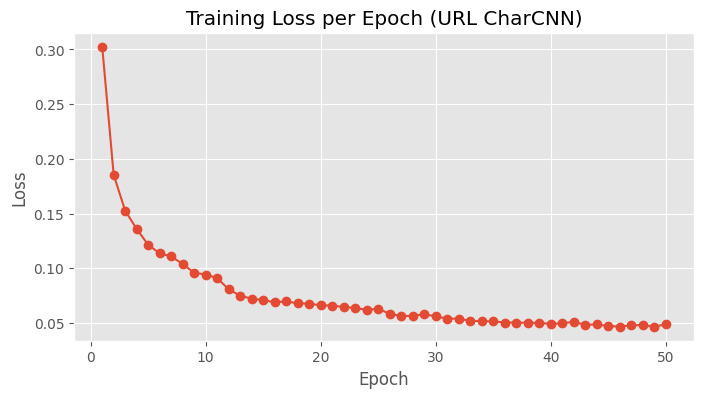

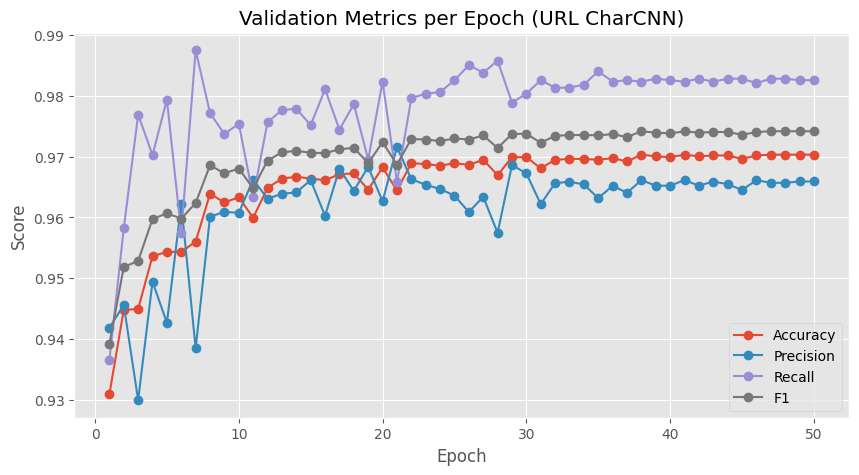

In [120]:
hist_df = pd.DataFrame(train_history)
display(hist_df)

# Loss curve
plt.figure(figsize=(8, 4))
plt.plot(hist_df["epoch"], hist_df["train_loss"], marker="o")
plt.title("Training Loss per Epoch (URL CharCNN)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# Metrics curve
plt.figure(figsize=(10, 5))
for col, label in [
    ("val_accuracy", "Accuracy"),
    ("val_precision", "Precision"),
    ("val_recall", "Recall"),
    ("val_f1", "F1"),
]:
    plt.plot(hist_df["epoch"], hist_df[col], marker="o", label=label)

plt.title("Validation Metrics per Epoch (URL CharCNN)")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()

# 12. Final Confusion Matrix & Classification Report

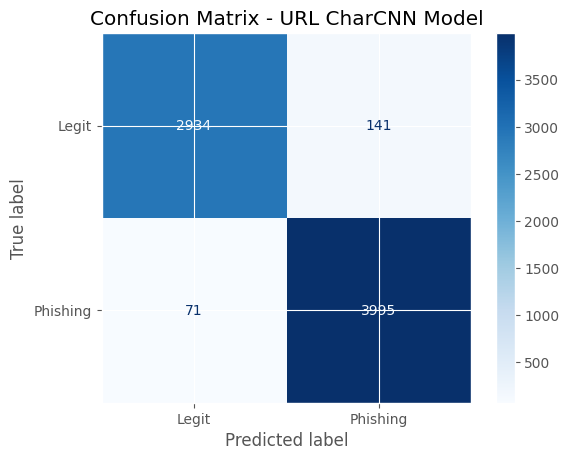


Classification Report (URL CharCNN):
              precision    recall  f1-score   support

       Legit       0.98      0.95      0.97      3075
    Phishing       0.97      0.98      0.97      4066

    accuracy                           0.97      7141
   macro avg       0.97      0.97      0.97      7141
weighted avg       0.97      0.97      0.97      7141



In [121]:
final_metrics = evaluate(model, val_loader, device)
y_true = final_metrics["labels"]
y_pred = final_metrics["preds"]

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legit", "Phishing"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - URL CharCNN Model")
plt.show()

print("\nClassification Report (URL CharCNN):")
print(classification_report(y_true, y_pred, target_names=["Legit", "Phishing"]))

# 13. Precision–Recall Curve

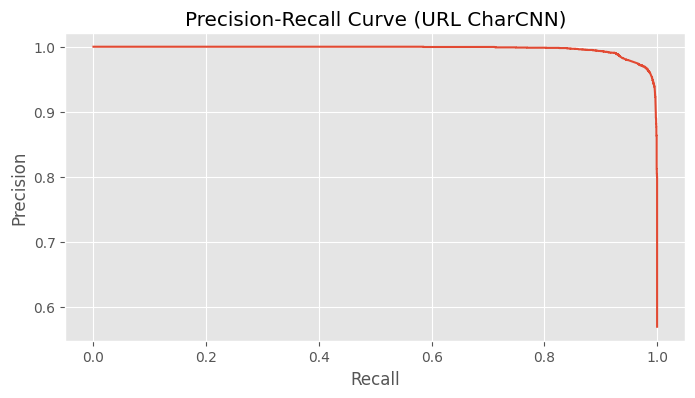

In [122]:
y_probs = final_metrics["probs"]

prec, rec, thresh = precision_recall_curve(y_true, y_probs)

plt.figure(figsize=(8, 4))
plt.plot(rec, prec)
plt.title("Precision-Recall Curve (URL CharCNN)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True)
plt.show()

# 14. Inference Helper

In [123]:
def encode_single_url(url: str) -> torch.Tensor:
    url_norm = normalize_url(url)
    ids = encode_url_text(url_norm, char2idx)
    return torch.tensor(ids, dtype=torch.long).unsqueeze(0).to(device) 

def predict_url(url: str):
    model.eval()
    x = encode_single_url(url)

    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1)[0].cpu().numpy()

    pred = int(np.argmax(probs))
    return {
        "url": url,
        "normalized": normalize_url(url),
        "prediction": "PHISHING" if pred == 1 else "LEGIT",
        "prob_legit": float(probs[0]),
        "prob_phishing": float(probs[1]),
    }



# Quick example:
while True:
    example = "http://login.secure-paypal.com/update?session=123"
    example = input("Input URL: ")
    if example.lower() in ['b', 'break']:
        break
    print(f"Example URL prediction:")
    for key, value in predict_url(example).items():
        print(f"{key}: {value}")

Example URL prediction:
url: google.com
normalized: google.com
prediction: PHISHING
prob_legit: 0.017459794878959656
prob_phishing: 0.9825401902198792
Example URL prediction:
url: yahoo.com
normalized: yahoo.com
prediction: PHISHING
prob_legit: 0.1891811639070511
prob_phishing: 0.8108187913894653
Example URL prediction:
url: yahoo,com
normalized: yahoo,com
prediction: PHISHING
prob_legit: 0.33333855867385864
prob_phishing: 0.6666615009307861
Example URL prediction:
url: clear
normalized: clear
prediction: LEGIT
prob_legit: 0.9970088601112366
prob_phishing: 0.002991184825077653
Example URL prediction:
url: advance
normalized: advance
prediction: PHISHING
prob_legit: 0.11266861110925674
prob_phishing: 0.8873313665390015
Example URL prediction:
url: hate you
normalized: hateyou
prediction: PHISHING
prob_legit: 0.006232460495084524
prob_phishing: 0.993767499923706
Example URL prediction:
url: clear
normalized: clear
prediction: LEGIT
prob_legit: 0.9970088601112366
prob_phishing: 0.00299118